In [ ]:
!pip install -q datasets transformers accelerate qwen-vl-utils pillow matplotlib
!pip install -q --force-reinstall "Pillow==11.3.0"
%cd satellite-image-change-detection
!mkdir -p notebooks src experiments results data
%cd notebooks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 59.8 MB/s eta 0:00:00
[Errno 2] No such file or directory: 'satellite-image-change-detection'
/content
/content/notebooks


In [ ]:
import PIL
print(PIL.__version__)

from PIL import Image
print("Pillow OK")

11.3.0
Pillow OK


In [ ]:
import os
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [ ]:
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(model_name)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

print("Model loaded")
print("Device:", model.device)

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded
Device: cuda:0


In [ ]:
dataset = load_dataset(
    "google/RSRCC",
    split="train",
    streaming=True
)

print("Dataset loaded")

README.md:   0%|          | 0.00/5.61k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/12835 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2521 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/3653 [00:00<?, ?it/s]

Dataset loaded


In [ ]:
experiments = []

for sample in dataset:

    text = sample["text"]
    parts = text.split("**Answer:**")

    if len(parts) < 2:
        continue

    answer = parts[1].strip()

    question = (
        parts[0]
        .replace("**Question:**", "")
        .replace("\\n", " ")
        .strip()
    )

    experiment = {
        "before": sample["before"],
        "after": sample["after"],
        "question": question,
        "ground_truth": answer
    }

    experiments.append(experiment)

    if len(experiments) == 1000:
        break

print("Number of experiments:", len(experiments))

Number of experiments: 1000


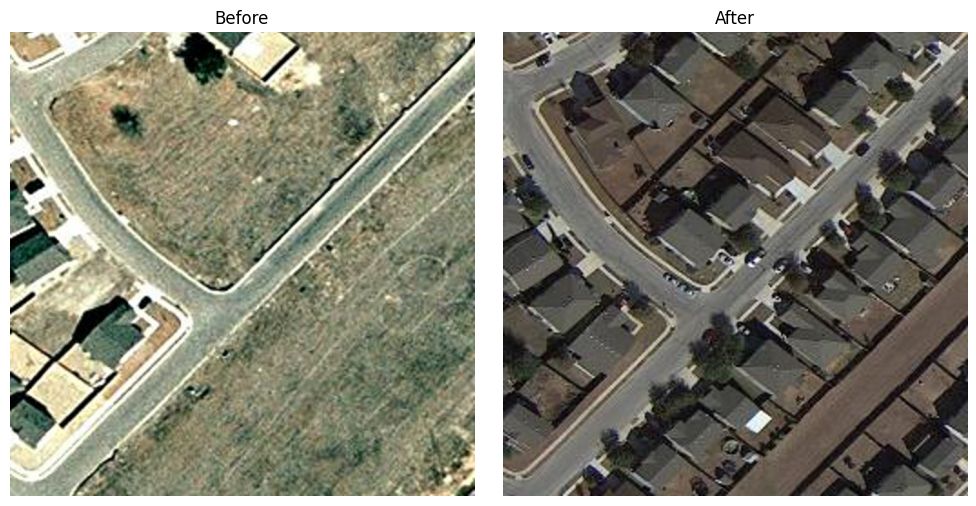

Question: In the western section of the neighborhood, has a tree been planted at the front corner of a residential lot near the curved street?
Ground truth: Yes


In [ ]:
sample = experiments[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sample["before"])
axes[0].set_title("Before")
axes[0].axis("off")

axes[1].imshow(sample["after"])
axes[1].set_title("After")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Question:", sample["question"])
print("Ground truth:", sample["ground_truth"])

In [ ]:
def check_prediction(ground_truth, prediction):

    ground_truth = ground_truth.strip().lower()
    prediction = prediction.strip().lower()

    return prediction.startswith(ground_truth)

In [ ]:
import re
import torch
from qwen_vl_utils import process_vision_info

def normalize_prediction(prediction, ground_truth):

    prediction = prediction.strip().lower()
    ground_truth = ground_truth.strip().lower()

    if ground_truth.startswith("yes") or ground_truth.startswith("no"):
        match = re.search(r"\b(yes|no)\b", prediction)

        if match:
            return match.group(1)

        return prediction

    match = re.search(
        r"(?:answer\s*:\s*)?\**\s*([abcd])\s*\)",
        prediction
    )

    if match:
        return match.group(1)

    match = re.match(r"^\s*\**\s*([abcd])\b", prediction)

    if match:
        return match.group(1)

    return prediction


def check_prediction(ground_truth, prediction):

    ground_truth = ground_truth.strip().lower()
    prediction = prediction.strip().lower()

    if ground_truth.startswith("yes"):
        return prediction == "yes"

    if ground_truth.startswith("no"):
        return prediction == "no"

    match = re.match(r"^\s*([abcd])", ground_truth)

    if match:
        return prediction == match.group(1)

    return False


for i, experiment in enumerate(experiments):

    ground_truth = experiment["ground_truth"].strip().lower()

    if ground_truth.startswith("yes") or ground_truth.startswith("no"):
        answer_instruction = "Answer only Yes or No."
    else:
        answer_instruction = "Answer only A, B, C, or D."

    prompt = f"""
Compare the BEFORE and AFTER images and answer the question.

{answer_instruction}

Do not explain your answer.
Do not describe the images.
Return only the final answer.

Question:
{experiment["question"]}
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": experiment["before"]
                },
                {
                    "type": "image",
                    "image": experiment["after"]
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    image_inputs, video_inputs = process_vision_info(messages)

    text_prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=text_prompt,
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=20
        )

    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )

    raw_prediction = output_text[0].strip()

    prediction = normalize_prediction(
        raw_prediction,
        experiment["ground_truth"]
    )

    experiment["raw_prediction"] = raw_prediction
    experiment["prediction"] = prediction

    experiment["correct"] = check_prediction(
        experiment["ground_truth"],
        prediction
    )

    print(f"Sample {i + 1}/{len(experiments)}")
    print("Ground truth:", experiment["ground_truth"])
    print("Raw prediction:", raw_prediction)
    print("Prediction:", prediction)
    print("Correct:", experiment["correct"])
    print("-" * 70)


correct_count = sum(
    experiment["correct"]
    for experiment in experiments
)

total_count = len(experiments)

accuracy = (
    correct_count / total_count * 100
    if total_count > 0
    else 0
)

print("\nTASK 1 BASELINE RESULT")
print("Correct:", correct_count)
print("Total:", total_count)
print("Accuracy:", round(accuracy, 2), "%")


yes_no_total = 0
yes_no_correct = 0

mc_total = 0
mc_correct = 0

for experiment in experiments:

    gt = experiment["ground_truth"].strip().lower()

    if gt.startswith("yes") or gt.startswith("no"):

        yes_no_total += 1

        if experiment["correct"]:
            yes_no_correct += 1

    else:

        mc_total += 1

        if experiment["correct"]:
            mc_correct += 1


yes_no_accuracy = (
    yes_no_correct / yes_no_total * 100
    if yes_no_total > 0
    else 0
)

mc_accuracy = (
    mc_correct / mc_total * 100
    if mc_total > 0
    else 0
)

print("\nYES/NO QUESTIONS")
print("Correct:", yes_no_correct)
print("Total:", yes_no_total)
print("Accuracy:", round(yes_no_accuracy, 2), "%")

print("\nMULTIPLE-CHOICE QUESTIONS")
print("Correct:", mc_correct)
print("Total:", mc_total)
print("Accuracy:", round(mc_accuracy, 2), "%")


print("\nINCORRECT PREDICTIONS")

for i, experiment in enumerate(experiments):

    if not experiment["correct"]:

        print(f"\nSample {i + 1}")
        print("Ground truth:", experiment["ground_truth"])
        print("Raw prediction:", experiment["raw_prediction"])
        print("Normalized prediction:", experiment["prediction"])
        print("-" * 70)

Streaming output truncated to the last 5000 lines.
Prediction: a
Correct: True
----------------------------------------------------------------------
Sample 353/1000
Ground truth: Yes
Raw prediction: Yes
Prediction: yes
Correct: True
----------------------------------------------------------------------
Sample 354/1000
Ground truth: Yes
Raw prediction: Yes
Prediction: yes
Correct: True
----------------------------------------------------------------------
Sample 355/1000
Ground truth: B
Raw prediction: B
Prediction: b
Correct: True
----------------------------------------------------------------------
Sample 356/1000
Ground truth: A
Raw prediction: D
Prediction: d
Correct: False
----------------------------------------------------------------------
Sample 357/1000
Ground truth: B
Raw prediction: B
Prediction: b
Correct: True
----------------------------------------------------------------------
Sample 358/1000
Ground truth: Yes
Raw prediction: Yes
Prediction: yes
Correct: True
--------

In [ ]:
correct_count = sum(
    experiment["correct"]
    for experiment in experiments
)

total_count = len(experiments)

accuracy = (
    correct_count / total_count
) * 100

print("=" * 60)
print("TASK 1 BASELINE RESULT")
print("=" * 60)
print("Correct:", correct_count)
print("Total:", total_count)
print("Accuracy:", round(accuracy, 2), "%")

TASK 1 BASELINE RESULT
Correct: 818
Total: 1000
Accuracy: 81.8 %


In [ ]:
yes_no_total = 0
yes_no_correct = 0

mc_total = 0
mc_correct = 0

for experiment in experiments:

    ground_truth = experiment["ground_truth"].strip().lower()

    if ground_truth.startswith(("yes", "no")):

        yes_no_total += 1

        if experiment["correct"]:
            yes_no_correct += 1

    else:

        mc_total += 1

        if experiment["correct"]:
            mc_correct += 1

print("Yes/No Questions")
print("Correct:", yes_no_correct)
print("Total:", yes_no_total)
print(
    "Accuracy:",
    round((yes_no_correct / yes_no_total) * 100, 2),
    "%"
)

print()

print("Multiple-Choice Questions")
print("Correct:", mc_correct)
print("Total:", mc_total)
print(
    "Accuracy:",
    round((mc_correct / mc_total) * 100, 2),
    "%"
)

Yes/No Questions
Correct: 477
Total: 520
Accuracy: 91.73 %

Multiple-Choice Questions
Correct: 341
Total: 480
Accuracy: 71.04 %


In [ ]:
import os
import pandas as pd

os.makedirs("../results", exist_ok=True)

results = []

for i, experiment in enumerate(experiments):

    gt = experiment["ground_truth"].strip()

    if gt.lower().startswith(("yes", "no")):
        question_type = "Yes/No"
    else:
        question_type = "Multiple Choice"

    results.append({
        "sample": i + 1,
        "question": experiment["question"],
        "ground_truth": gt,
        "raw_prediction": experiment["raw_prediction"],
        "prediction": experiment["prediction"],
        "correct": experiment["correct"],
        "question_type": question_type
    })

results_df = pd.DataFrame(results)

results_df.to_csv(
    "../results/task1_baseline_results.csv",
    index=False
)

print("Saved successfully")
print("File:", "../results/1000/task1_baseline_results.csv")
print("Samples:", len(results_df))

Saved successfully
File: ../results/task1_baseline_results.csv
Samples: 1000


In [ ]:
test_dataset = load_dataset(
    "google/RSRCC",
    split="test",
    streaming=True
)

test_experiments = []

for sample in test_dataset:

    parts = sample["text"].split("**Answer:**")

    if len(parts) < 2:
        continue

    question = (
        parts[0]
        .replace("**Question:**", "")
        .replace("\\n", " ")
        .strip()
    )

    answer = parts[1].strip()

    test_experiments.append({
        "before": sample["before"],
        "after": sample["after"],
        "question": question,
        "ground_truth": answer
    })

    if len(test_experiments) == 100:
        break

print("Test samples prepared:", len(test_experiments))

Resolving data files:   0%|          | 0/12835 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2521 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/3653 [00:00<?, ?it/s]

Test samples prepared: 100


In [ ]:
import re
import torch
from qwen_vl_utils import process_vision_info

def normalize_prediction(prediction, ground_truth):
    prediction = prediction.strip().lower()
    ground_truth = ground_truth.strip().lower()

    if ground_truth.startswith(("yes", "no")):
        match = re.search(r"\b(yes|no)\b", prediction)
        return match.group(1) if match else prediction

    match = re.search(r"\b([abcd])\b", prediction)
    return match.group(1) if match else prediction

def check_prediction(ground_truth, prediction):
    gt = ground_truth.strip().lower()
    pred = prediction.strip().lower()

    if gt.startswith(("yes", "no")):
        expected = "yes" if gt.startswith("yes") else "no"
        return pred == expected

    match = re.match(r"^\s*([abcd])", gt)
    if not match:
        return False

    return pred == match.group(1)

for i, experiment in enumerate(test_experiments):

    prompt = f"""
Compare the BEFORE image with the AFTER image.

Answer the question using the visual changes between the two images.

If the question is Yes/No, answer only:
Yes
or
No

If the question is multiple choice, answer only:
A
B
C
or
D

Do not explain your answer.

Question:
{experiment["question"]}
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": experiment["before"]
                },
                {
                    "type": "image",
                    "image": experiment["after"]
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    image_inputs, video_inputs = process_vision_info(messages)

    text_prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=text_prompt,
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=10
        )

    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids
        in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )

    raw_prediction = output_text[0].strip()

    prediction = normalize_prediction(
        raw_prediction,
        experiment["ground_truth"]
    )

    experiment["raw_prediction"] = raw_prediction
    experiment["prediction"] = prediction

    experiment["correct"] = check_prediction(
        experiment["ground_truth"],
        prediction
    )

    print(
        f"Sample {i + 1}/{len(test_experiments)} | "
        f"GT: {experiment['ground_truth']} | "
        f"Prediction: {prediction} | "
        f"Correct: {experiment['correct']}"
    )

Sample 1/100 | GT: B | Prediction: b | Correct: True
Sample 2/100 | GT: Yes | Prediction: yes | Correct: True
Sample 3/100 | GT: B | Prediction: b | Correct: True
Sample 4/100 | GT: No | Prediction: no | Correct: True
Sample 5/100 | GT: B | Prediction: b | Correct: True
Sample 6/100 | GT: No | Prediction: yes | Correct: False
Sample 7/100 | GT: Yes | Prediction: yes | Correct: True
Sample 8/100 | GT: Yes | Prediction: yes | Correct: True
Sample 9/100 | GT: A | Prediction: c | Correct: False
Sample 10/100 | GT: Yes | Prediction: yes | Correct: True
Sample 11/100 | GT: Yes | Prediction: no | Correct: False
Sample 12/100 | GT: A | Prediction: a | Correct: True
Sample 13/100 | GT: Yes | Prediction: yes | Correct: True
Sample 14/100 | GT: A | Prediction: a | Correct: True
Sample 15/100 | GT: B | Prediction: b | Correct: True
Sample 16/100 | GT: B | Prediction: b | Correct: True
Sample 17/100 | GT: Yes | Prediction: yes | Correct: True
Sample 18/100 | GT: Yes | Prediction: yes | Correct: Tru

In [ ]:
import pandas as pd
import os

results = []

for i, experiment in enumerate(test_experiments):

    gt = experiment["ground_truth"].strip()

    if gt.lower().startswith(("yes", "no")):
        question_type = "Yes/No"
    else:
        question_type = "Multiple Choice"

    results.append({
        "sample": i + 1,
        "question": experiment["question"],
        "ground_truth": gt,
        "raw_prediction": experiment["raw_prediction"],
        "prediction": experiment["prediction"],
        "correct": experiment["correct"],
        "question_type": question_type
    })

results_df = pd.DataFrame(results)

os.makedirs("../results", exist_ok=True)

results_df.to_csv(
    "../results/task1_test_baseline_results.csv",
    index=False
)

print("Saved:", len(results_df), "results")
print("../results/task1_test_baseline_results.csv")

Saved: 100 results
../results/task1_test_baseline_results.csv


In [ ]:
print("Total samples:", len(results_df))
print("Correct:", results_df["correct"].sum())
print("Accuracy:", round(results_df["correct"].mean() * 100, 2), "%")

Total samples: 100
Correct: 76
Accuracy: 76.0 %
